In [9]:
import importlib.metadata as metadata

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import camb
from camb import model
from classy import Class
import baccoemu

plt.rcParams.update({"figure.figsize": (7.2, 5.6), "font.size": 12})

def package_version(name):
    try:
        return metadata.version(name)
    except metadata.PackageNotFoundError:
        return "unknown"

print(f"CAMB    {package_version('camb')}")
print(f"CLASS   {package_version('classy')}")
print(f"BACCO   {package_version('baccoemu')}")


CAMB    1.6.6
CLASS   3.3.4.0
BACCO   2.3.0


## Cosmology

The physical densities `ombh2` and `omch2` are passed directly to CAMB and CLASS.  BACCO expects density parameters without the factor of $h^2$, so we convert explicitly below.


In [10]:
cosmo = {
    "h": 0.6736,
    "H0": 67.36,
    "ombh2": 0.02237,
    "omch2": 0.1200,
    "As": 2.1e-9,
    "ns": 0.9649,
    "mnu": 0.06,      # total neutrino mass [eV]
    "tau": 0.0544,
    "w0": -1.0,
    "wa": 0.0,
    "z": 0.0,
}

h = cosmo["h"]
z = cosmo["z"]
a = 1.0 / (1.0 + z)
omega_b = cosmo["ombh2"] / h**2
omega_cdm = cosmo["omch2"] / h**2
omega_cold = omega_b + omega_cdm

## Common grid and unit convention

CAMB and BACCO below are requested directly in the plotting convention, $k$ in $h\,{\rm Mpc}^{-1}$ and $P$ in $(h^{-1}{\rm Mpc})^3$.

CLASS's `pk_cb_lin(k,z)` interface instead takes $k$ in ${\rm Mpc}^{-1}$ and returns $P$ in ${\rm Mpc}^3$.  In the CLASS cell this is converted directly with

$$k_{\rm CLASS}[{\rm Mpc}^{-1}] = h\,k[h\,{\rm Mpc}^{-1}], \qquad
P[(h^{-1}{\rm Mpc})^3] = h^3 P_{\rm CLASS}[{\rm Mpc}^3].$$


In [11]:
k_h = np.logspace(-4, np.log10(4.9), 600)  # h/Mpc; BACCO nonlinear is used only over this range.
k_check = np.array([1e-3, 1e-2, 1e-1, 1.0])


## CAMB

In [12]:
pars = camb.CAMBparams()
pars.set_cosmology(
    H0=cosmo["H0"],
    ombh2=cosmo["ombh2"],
    omch2=cosmo["omch2"],
    mnu=cosmo["mnu"],
    omk=0.0,
    tau=cosmo["tau"],
)
pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
pars.set_matter_power(redshifts=[z], kmax=10.0)
pars.NonLinear = model.NonLinear_none

camb_results = camb.get_results(pars)
k_camb_h, z_camb, P_camb_cb = camb_results.get_matter_power_spectrum(
    minkh=1e-4,
    maxkh=10.0,
    npoints=1200,
    var1=model.Transfer_nonu,
    var2=model.Transfer_nonu,
)
P_camb_cb = P_camb_cb[0]
P_camb_cb_grid = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_cb), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)

_, _, P_camb_total = camb_results.get_matter_power_spectrum(minkh=1e-4, maxkh=10.0, npoints=1200)
P_camb_total = P_camb_total[0]
P_camb_total_grid = np.exp(
    interp1d(np.log(k_camb_h), np.log(P_camb_total), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)



## CLASS 


In [13]:
class_params = {
    "output": "mPk",
    "h": h,
    "omega_b": cosmo["ombh2"],
    "omega_cdm": cosmo["omch2"],
    "A_s": cosmo["As"],
    "n_s": cosmo["ns"],
    "tau_reio": cosmo["tau"],
    "N_ncdm": 1,
    "m_ncdm": cosmo["mnu"],
    "N_ur": 2.0328,
    "P_k_max_h/Mpc": 10.0,
    "z_pk": z,
}

class_cosmo = Class()
class_cosmo.set(class_params)
class_cosmo.compute()

P_class_cb_grid = h**3 * np.array([class_cosmo.pk_cb_lin(float(h * kk), z) for kk in k_h])

## BACCO 

In [18]:
bacco_kwargs = dict(
    omega_cold=omega_cold,
    omega_baryon=omega_b,
    A_s=cosmo["As"],
    hubble=h,
    ns=cosmo["ns"],
    neutrino_mass=cosmo["mnu"],
    w0=cosmo["w0"],
    wa=cosmo["wa"],
    expfactor=a,
    k=k_h,
    cold=True,
)

mp_bacco = baccoemu.Matter_powerspectrum(
    linear=True,
    nonlinear_boost=True,
    baryonic_boost=False,
    verbose=False,
)

k_bacco_lin_h, P_bacco_lin = mp_bacco.get_linear_pk(**bacco_kwargs)
k_bacco_nl_h, P_bacco_nl = mp_bacco.get_nonlinear_pk(**bacco_kwargs, baryonic_boost=False)

P_bacco_lin_grid = np.exp(
    interp1d(np.log(k_bacco_lin_h), np.log(P_bacco_lin), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)
P_bacco_nl_grid = np.exp(
    interp1d(np.log(k_bacco_nl_h), np.log(P_bacco_nl), kind="linear", bounds_error=False, fill_value=np.nan)(np.log(k_h))
)


## Plot

All curves below are $P_{cb}$, not total matter.  The lower panel uses the CAMB linear cb spectrum as the reference.


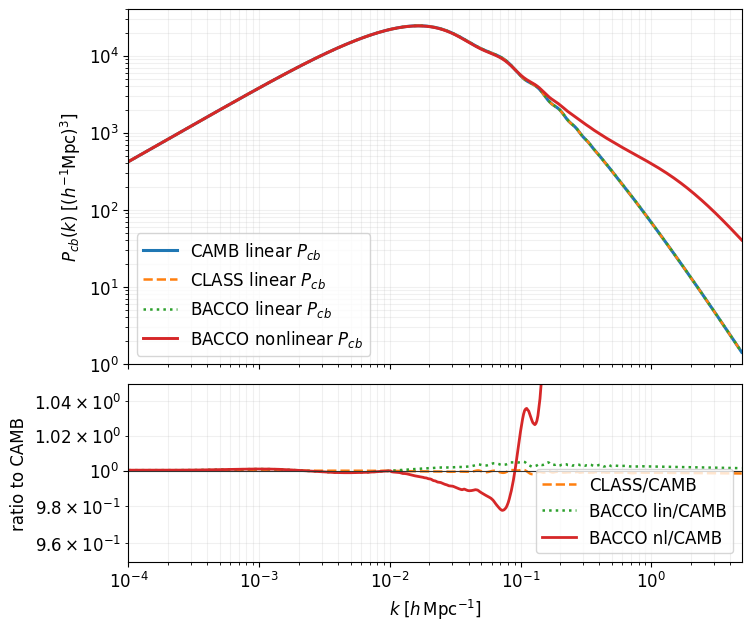

In [17]:
fig, (ax, axr) = plt.subplots(
    2,
    1,
    figsize=(7.4, 6.2),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

ax.loglog(k_h, P_camb_cb_grid, color="C0", lw=2.2, label=r"CAMB linear $P_{cb}$")
ax.loglog(k_h, P_class_cb_grid, color="C1", lw=1.8, ls="--", label=r"CLASS linear $P_{cb}$")
ax.loglog(k_h, P_bacco_lin_grid, color="C2", lw=1.8, ls=":", label=r"BACCO linear $P_{cb}$")
ax.loglog(k_h, P_bacco_nl_grid, color="C3", lw=2.1, label=r"BACCO nonlinear $P_{cb}$")

ax.set_ylabel(r"$P_{cb}(k)\;[(h^{-1}{\rm Mpc})^3]$")
ax.set_ylim(1e0, 4e4)
ax.legend()
ax.grid(True, which="both", alpha=0.18)

axr.semilogx(k_h, P_class_cb_grid / P_camb_cb_grid, color="C1", lw=1.8, ls="--", label="CLASS/CAMB")
axr.semilogx(k_h, P_bacco_lin_grid / P_camb_cb_grid, color="C2", lw=1.8, ls=":", label="BACCO lin/CAMB")
axr.semilogx(k_h, P_bacco_nl_grid / P_camb_cb_grid, color="C3", lw=2.0, label="BACCO nl/CAMB")
axr.axhline(1.0, color="0.2", lw=0.8)

axr.set_xlabel(r"$k\;[h\,{\rm Mpc}^{-1}]$")
axr.set_ylabel("ratio to CAMB")
axr.set_xlim(k_h.min(), k_h.max())
axr.set_yscale("log")
axr.set_ylim(0.95,1.05)
axr.legend()
axr.grid(True, which="both", alpha=0.18)
